# Temporal v1 Fixed Evaluation

Compare trained temporal cache-probe checkpoints on the same fixed validation set. This notebook is aligned with the current tick-extrema objective: each future chunk predicts normalized low/high absolute ticks plus up/down/path class logits. Confusion matrices come directly from the classification heads.

Default selection is the two linear-probe runs you trained for the new target: `epoch1` and `latest`. Update `RUN_NAME_MATCHES` or set `CHECKPOINTS` explicitly if needed.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd()
while REPO_ROOT.name != 'quant-research-workbench' and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from research.temporal_event_model.v1.evaluate_cache_probe_checkpoints import evaluate_checkpoints

CACHE_ROOT = Path(r'D:\market-data\prepared\event_sample_cache\cache_v2_cycle_20260619_134422')
CHECKPOINT_ROOT = Path(r'D:\TradingML\runtimes\temporal_event_model\v1\cache_price_probe_laptop')
OUTPUT_DIR = Path(r'D:\TradingML\runtimes\temporal_event_model\v1\cache_price_probe_laptop_eval\tickextrema-fixed-shard1-10x1024')

# Leave CHECKPOINTS empty to select checkpoint_latest.pt files by run-name match.
CHECKPOINTS = []
RUN_NAME_MATCHES = [
    'v1-tickextrema-probe-v20-epoch1',
    'v1-tickextrema-probe-v20-latest',
]

BATCH_SIZE = 1024
VALIDATION_BATCHES = 10
SEED = 20260621
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_DTYPE = torch.bfloat16 if DEVICE.type == 'cuda' else None

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'device={DEVICE}')
print(f'cache_root={CACHE_ROOT}')
print(f'checkpoint_root={CHECKPOINT_ROOT}')
print(f'output_dir={OUTPUT_DIR}')


device=cuda
cache_root=D:\market-data\prepared\event_sample_cache\cache_v2_cycle_20260619_134422
checkpoint_root=D:\TradingML\runtimes\temporal_event_model\v1\cache_price_probe_laptop
output_dir=D:\TradingML\runtimes\temporal_event_model\v1\cache_price_probe_laptop_eval\tickextrema-fixed-shard1-10x1024


In [2]:
def select_checkpoints(checkpoint_root: Path, run_name_matches: list[str], explicit: list[str | Path]) -> list[Path]:
    if explicit:
        return [Path(path) for path in explicit]
    candidates = sorted(
        checkpoint_root.glob('*/checkpoints/checkpoint_latest.pt'),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    selected = []
    seen = set()
    for pattern in run_name_matches:
        for path in candidates:
            run_name = path.parent.parent.name
            if pattern in run_name and path not in seen:
                selected.append(path)
                seen.add(path)
                break
    if not selected:
        selected = candidates[:3]
    return selected

checkpoint_paths = select_checkpoints(CHECKPOINT_ROOT, RUN_NAME_MATCHES, CHECKPOINTS)
print('Checkpoints:')
for path in checkpoint_paths:
    print(' ', path)

result = evaluate_checkpoints(
    checkpoint_paths=checkpoint_paths,
    cache_root=CACHE_ROOT,
    validation_split='train',
    validation_start_shard=1,
    validation_max_shards=1,
    validation_batches=VALIDATION_BATCHES,
    batch_size=BATCH_SIZE,
    seed=SEED,
    device=DEVICE,
    amp_dtype=AMP_DTYPE,
    output_dir=OUTPUT_DIR,
)
result_path = Path(result['result_path'])
print(f'wrote {result_path}')


Checkpoints:
  D:\TradingML\runtimes\temporal_event_model\v1\cache_price_probe_laptop\v1-tickextrema-probe-v20-epoch1-1train1val-5ep-bs1024-laptop\checkpoints\checkpoint_latest.pt
  D:\TradingML\runtimes\temporal_event_model\v1\cache_price_probe_laptop\v1-tickextrema-probe-v20-latest-1train1val-5ep-bs1024-laptop\checkpoints\checkpoint_latest.pt
wrote D:\TradingML\runtimes\temporal_event_model\v1\cache_price_probe_laptop_eval\tickextrema-fixed-shard1-10x1024\fixed_eval_results.json


In [3]:
# To skip recomputation in later notebook runs, comment the previous cell and load the saved result here.
result_path = OUTPUT_DIR / 'fixed_eval_results.json'
result = json.loads(result_path.read_text(encoding='utf-8'))
up_class_names = result['up_class_names']
down_class_names = result['down_class_names']
path_class_names = result['path_class_names']
summary = result['summary']
pd.DataFrame(summary)


,run_name,checkpoint,step,epoch,loss,regression_mse,classification_loss,path_accuracy_pct,low_tick_mae,high_tick_mae,low_price_mae_dollars,high_price_mae_dollars,seconds
0,v1-tickextrema-probe-v20-epoch1-1train1val-5ep...,D:\TradingML\runtimes\temporal_event_model\v1\...,13500,5,0.870585,0.000042,0.870543,57.617188,2540.956763,2628.387866,22.829791,23.310135,9.114985
1,v1-tickextrema-probe-v20-latest-1train1val-5ep...,D:\TradingML\runtimes\temporal_event_model\v1\...,13500,5,0.870133,0.000043,0.870090,57.646484,2511.304199,2611.610791,22.677839,23.234952,1.369384


In [4]:
def short_name(run: dict) -> str:
    name = run['summary']['run_name']
    replacements = [
        ('v1-tickextrema-probe-v20-', ''),
        ('v1-extrema-probe-v20-', ''),
        ('-1train1val-5ep-bs512-laptop', ''),
        ('-1train1val-5ep-bs1024-laptop', ''),
        ('v1-cache-probe-v20-', ''),
    ]
    for old, new in replacements:
        name = name.replace(old, new)
    return name

rows = []
for run in result['runs']:
    row = {'run': short_name(run), **run['summary']}
    rows.append(row)
summary_df = pd.DataFrame(rows)
summary_df


,run,run_name,checkpoint,step,epoch,loss,regression_mse,classification_loss,path_accuracy_pct,low_tick_mae,high_tick_mae,low_price_mae_dollars,high_price_mae_dollars,seconds
0,epoch1,v1-tickextrema-probe-v20-epoch1-1train1val-5ep...,D:\TradingML\runtimes\temporal_event_model\v1\...,13500,5,0.870585,0.000042,0.870543,57.617188,2540.956763,2628.387866,22.829791,23.310135,9.114985
1,latest,v1-tickextrema-probe-v20-latest-1train1val-5ep...,D:\TradingML\runtimes\temporal_event_model\v1\...,13500,5,0.870133,0.000043,0.870090,57.646484,2511.304199,2611.610791,22.677839,23.234952,1.369384


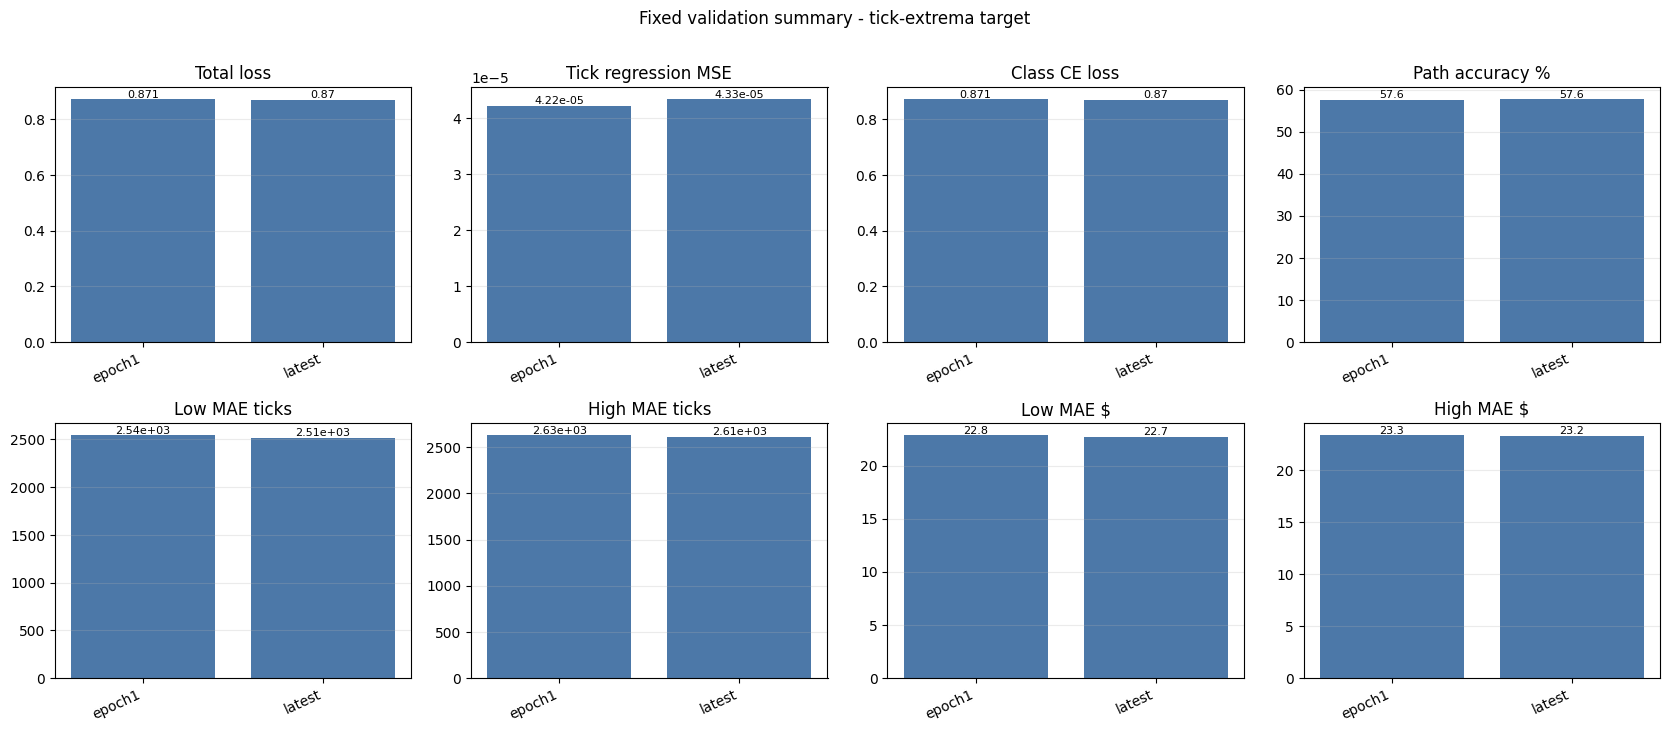

In [5]:
metric_columns = [
    ('loss', 'Total loss'),
    ('regression_mse', 'Tick regression MSE'),
    ('classification_loss', 'Class CE loss'),
    ('upside_accuracy_pct', 'Upside accuracy %'),
    ('downside_accuracy_pct', 'Downside accuracy %'),
    ('path_accuracy_pct', 'Path accuracy %'),
    ('path_macro_f1_pct', 'Path macro F1 %'),
    ('low_tick_mae', 'Low MAE ticks'),
    ('high_tick_mae', 'High MAE ticks'),
    ('low_price_mae_dollars', 'Low MAE $'),
    ('high_price_mae_dollars', 'High MAE $'),
]

available = [(column, title) for column, title in metric_columns if column in summary_df.columns]
cols = 4
rows = int(np.ceil(len(available) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.6 * rows), squeeze=False)
labels = summary_df['run'].tolist()
x = np.arange(len(labels))
for ax, (column, title) in zip(axes.ravel(), available):
    values = summary_df[column].astype(float).to_numpy()
    ax.bar(x, values, color='#4C78A8')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha='right')
    ax.grid(axis='y', alpha=0.25)
    for idx, value in enumerate(values):
        ax.text(idx, value, f'{value:.3g}', ha='center', va='bottom', fontsize=8)
for ax in axes.ravel()[len(available):]:
    ax.axis('off')
fig.suptitle('Fixed validation summary - tick-extrema target', y=1.01)
fig.tight_layout()
plt.show()


In [6]:
def normalize_rows(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=np.float64)
    denom = matrix.sum(axis=1, keepdims=True)
    return np.divide(matrix, np.maximum(denom, 1.0)) * 100.0


def plot_confusion(ax, matrix, labels, title, normalize=True):
    matrix = np.asarray(matrix, dtype=np.float64)
    values = normalize_rows(matrix) if normalize else matrix
    im = ax.imshow(values, cmap='Blues', vmin=0)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    threshold = values.max() * 0.55 if values.size else 0
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if normalize:
                text = f'{values[i, j]:.1f}%\n({int(matrix[i, j]):,})'
            else:
                text = f'{int(values[i, j]):,}'
            ax.text(j, i, text, ha='center', va='center', color='white' if values[i, j] > threshold else 'black', fontsize=8)
    return im


def confusion_distribution(matrix, labels):
    matrix = np.asarray(matrix, dtype=np.float64)
    target = matrix.sum(axis=1)
    predicted = matrix.sum(axis=0)
    total = max(float(matrix.sum()), 1.0)
    return pd.DataFrame({
        'class': labels,
        'target_count': target.astype(int),
        'pred_count': predicted.astype(int),
        'target_pct': target / total * 100.0,
        'pred_pct': predicted / total * 100.0,
    })


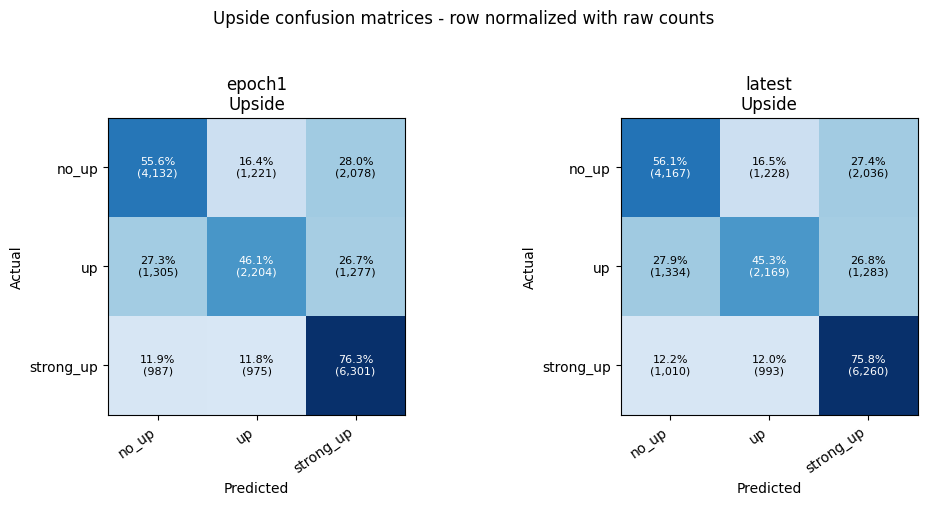

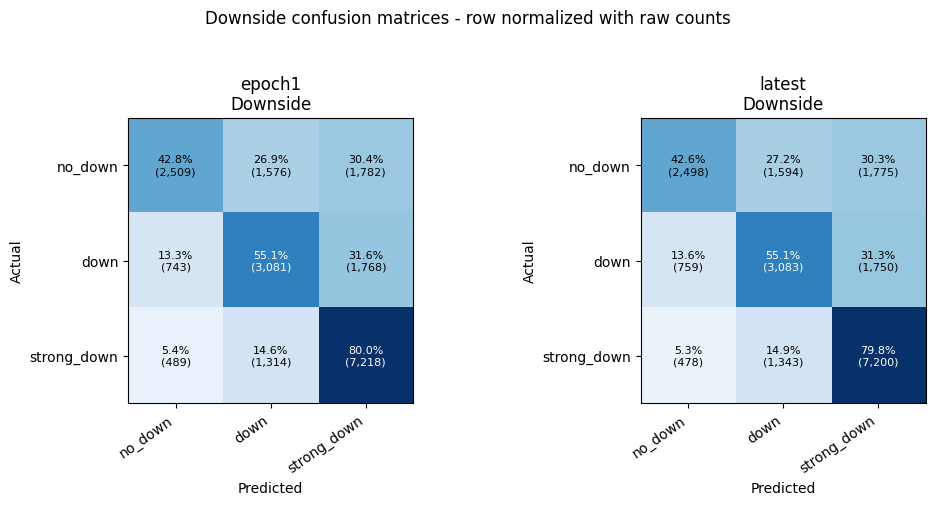

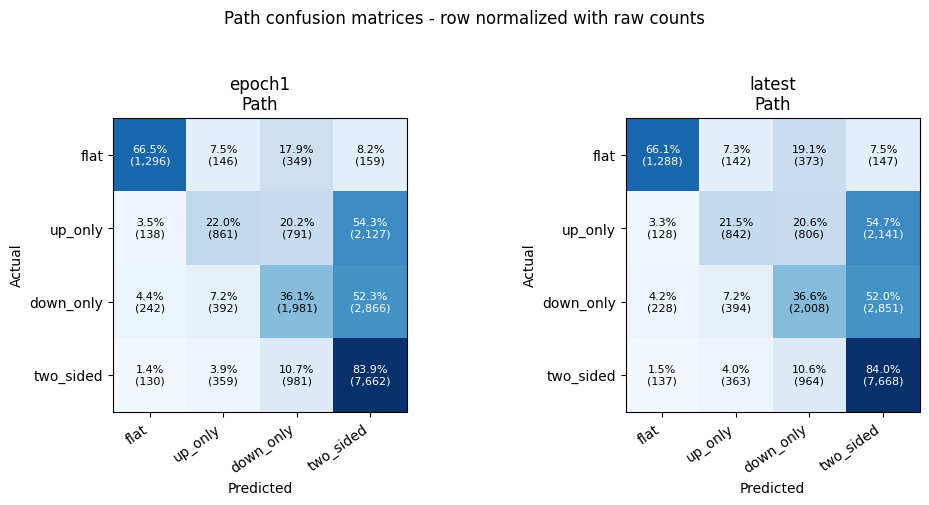

In [7]:
matrix_specs = [
    ('upside', up_class_names, 'Upside'),
    ('downside', down_class_names, 'Downside'),
    ('path', path_class_names, 'Path'),
]

for matrix_key, class_labels, title in matrix_specs:
    fig, axes = plt.subplots(1, len(result['runs']), figsize=(5.2 * len(result['runs']), 4.8), squeeze=False)
    for col, run in enumerate(result['runs']):
        matrix = run['confusion_matrices'][matrix_key]
        plot_confusion(axes[0, col], matrix, class_labels, f'{short_name(run)}\n{title}', normalize=True)
    fig.suptitle(f'{title} confusion matrices - row normalized with raw counts', y=1.04)
    fig.tight_layout()
    plt.show()


,run,matrix,class,target_count,pred_count,target_pct,pred_pct
0,epoch1,Upside,no_up,7431,6424,36.284180,31.367188
1,epoch1,Upside,up,4786,4400,23.369141,21.484375
2,epoch1,Upside,strong_up,8263,9656,40.346680,47.148438
3,epoch1,Downside,no_down,5867,3741,28.647461,18.266602
4,epoch1,Downside,down,5592,5971,27.304688,29.155273
5,epoch1,Downside,strong_down,9021,10768,44.047852,52.578125
6,epoch1,Path,flat,1950,1806,9.521484,8.818359
7,epoch1,Path,up_only,3917,1758,19.125977,8.583984
8,epoch1,Path,down_only,5481,4102,26.762695,20.029297
9,epoch1,Path,two_sided,9132,12814,44.589844,62.568359


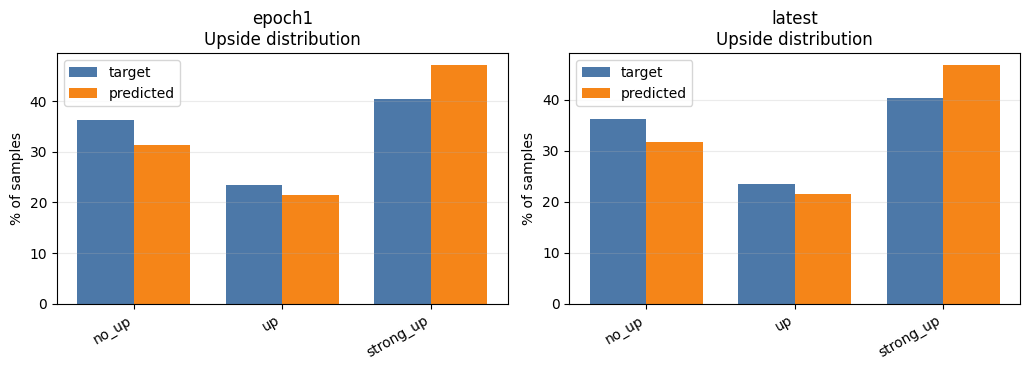

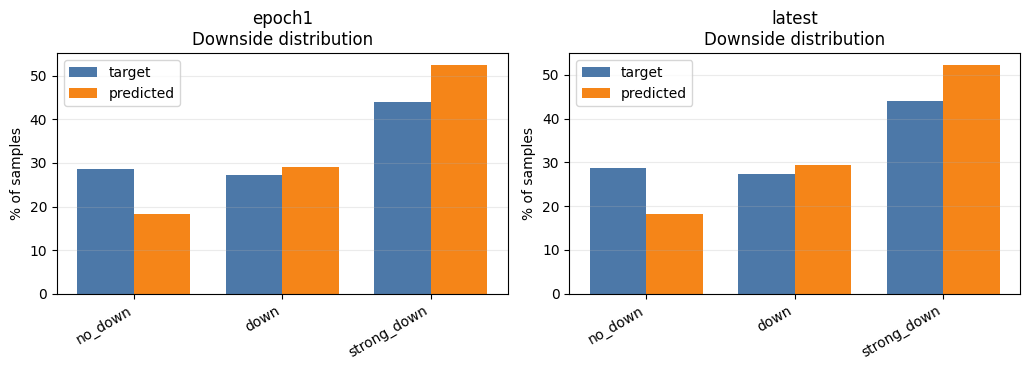

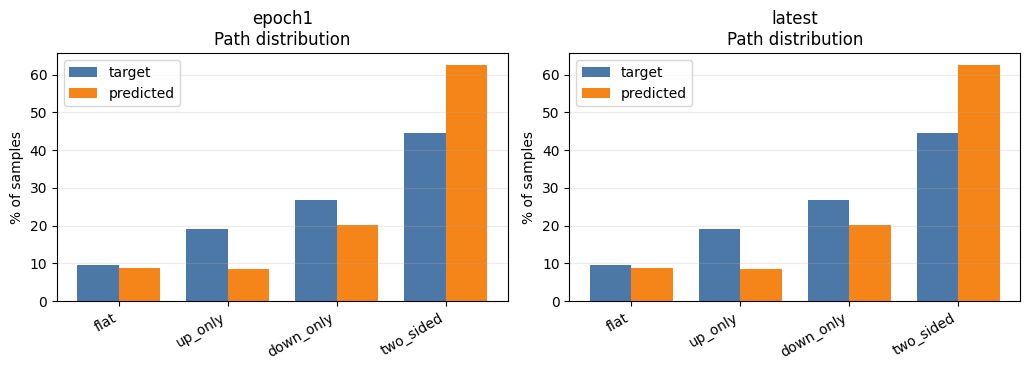

In [8]:
# Target versus predicted class distribution. This makes collapse/bias visible without reading every cell.
distribution_rows = []
for run in result['runs']:
    for matrix_key, class_labels, title in matrix_specs:
        frame = confusion_distribution(run['confusion_matrices'][matrix_key], class_labels)
        frame.insert(0, 'matrix', title)
        frame.insert(0, 'run', short_name(run))
        distribution_rows.append(frame)
distribution_df = pd.concat(distribution_rows, ignore_index=True)
display(distribution_df)

for matrix_key, class_labels, title in matrix_specs:
    fig, axes = plt.subplots(1, len(result['runs']), figsize=(5.2 * len(result['runs']), 3.8), squeeze=False)
    for col, run in enumerate(result['runs']):
        frame = confusion_distribution(run['confusion_matrices'][matrix_key], class_labels)
        x = np.arange(len(class_labels))
        width = 0.38
        ax = axes[0, col]
        ax.bar(x - width / 2, frame['target_pct'], width, label='target', color='#4C78A8')
        ax.bar(x + width / 2, frame['pred_pct'], width, label='predicted', color='#F58518')
        ax.set_title(f"{short_name(run)}\n{title} distribution")
        ax.set_xticks(x)
        ax.set_xticklabels(class_labels, rotation=30, ha='right')
        ax.set_ylabel('% of samples')
        ax.grid(axis='y', alpha=0.25)
        ax.legend()
    fig.tight_layout()
    plt.show()


In [ ]:
# Raw metrics for deeper inspection.
for run in result['runs']:
    print('\n' + '=' * 100)
    print(short_name(run))
    print(json.dumps(run['metrics'], indent=2))



epoch1
{
  "loss": 0.8705847322940826,
  "regression_mse": 4.2224384742439725e-05,
  "classification_loss": 0.8705425083637237,
  "up_class_loss": 0.8300265729427337,
  "down_class_loss": 0.8149193108081818,
  "path_class_loss": 0.9666815161705017,
  "valid_pct": 100.0,
  "low_tick_mae": 2540.9567626953126,
  "high_tick_mae": 2628.3878662109373,
  "low_price_mae_dollars": 22.82979106903076,
  "high_price_mae_dollars": 23.310134506225587,
  "valid_low_high_order_pct": 63.3740234375,
  "upside_accuracy_pct": 61.7041015625,
  "downside_accuracy_pct": 62.5390625,
  "path_accuracy_pct": 57.6171875,
  "path_macro_f1_pct": 52.61322174072266,
  "upside_confusion/no_up_pred_no_up": 4132.0,
  "upside_confusion/no_up_pred_up": 1221.0,
  "upside_confusion/no_up_pred_strong_up": 2078.0,
  "upside_confusion/up_pred_no_up": 1305.0,
  "upside_confusion/up_pred_up": 2204.0,
  "upside_confusion/up_pred_strong_up": 1277.0,
  "upside_confusion/strong_up_pred_no_up": 987.0,
  "upside_confusion/strong_up_p

: 